
# Lab Experiment 7 - Random Forest Classifier
# Dataset: Dry Bean Dataset (OpenML ID: 44225)


In [134]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder


# Task 1: Exploratory Data Analysis (EDA)

In [135]:
# Load dataset
data = fetch_openml(data_id=44225, as_frame=True)
df = data.frame.copy()

# Display shape and preview
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (10362, 15)


,MEMBERSHIP_NUMBER,MEMBERSHIP_TERM_YEARS,ANNUAL_FEES,MEMBER_MARITAL_STATUS,MEMBER_GENDER,MEMBER_ANNUAL_INCOME,MEMBER_OCCUPATION_CD,MEMBERSHIP_PACKAGE,MEMBER_AGE_AT_ISSUE,ADDITIONAL_MEMBERS,PAYMENT_MODE,AGENT_CODE,MEMBERSHIP_STATUS,START_DATE (YYYYMMDD),END_DATE (YYYYMMDD)
0,A00001,29,113125.0,M,M,25200000.0,1.0,TYPE-B,45,2,ANNUAL,477,INFORCE,20060914,NaN
1,A00002,38,112220.0,M,M,10339200.0,1.0,TYPE-B,36,3,QUARTERLY,255,INFORCE,20061102,NaN
2,A00003,12,100000.0,M,M,14400000.0,1.0,TYPE-B,42,1,ANNUAL,7866,INFORCE,20070124,NaN
3,A00004,12,100000.0,M,M,9000000.0,1.0,TYPE-B,39,2,ANNUAL,200533,INFORCE,20070122,NaN
4,A00005,46,100000.0,M,M,4800000.0,1.0,TYPE-B,27,2,QUARTERLY,6988,INFORCE,20070131,NaN


Class Distribution:
MEMBERSHIP_STATUS
INFORCE      7219
CANCELLED    3143
Name: count, dtype: int64


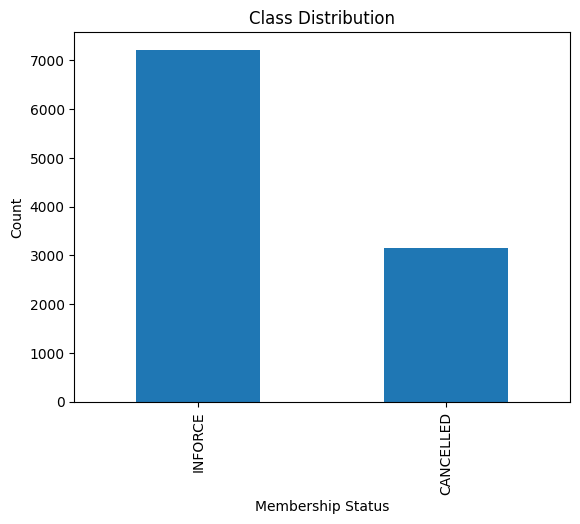

In [136]:
print("Class Distribution:")
print(df['MEMBERSHIP_STATUS'].value_counts())

df['MEMBERSHIP_STATUS'].value_counts().plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Membership Status')
plt.ylabel('Count')
plt.show()

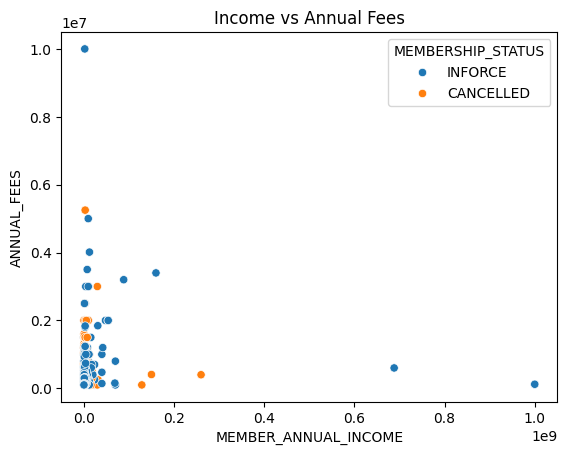

In [137]:
#Task 1: Visualization
sns.scatterplot(
    data=df,
    x='MEMBER_ANNUAL_INCOME',
    y='ANNUAL_FEES',
    hue='MEMBERSHIP_STATUS'
)

plt.title('Income vs Annual Fees')
plt.show()

# Task 2: Data Cleaning & Transformation

In [138]:

# Clean column names properly (fix spacing issue)
df.columns = df.columns.str.replace(r'\s+', ' ', regex=True).str.strip()

# Now drop columns
df = df.drop([
    'MEMBERSHIP_NUMBER',
    'START_DATE (YYYYMMDD)',
    'END_DATE (YYYYMMDD)',   # NOW it will match
    'AGENT_CODE'
], axis=1, errors='ignore')
# Check missing values
print("Missing Values Before Cleaning:\n", df.isnull().sum())

Missing Values Before Cleaning:
 MEMBERSHIP_TERM_YEARS       0
ANNUAL_FEES                 0
MEMBER_MARITAL_STATUS    2597
MEMBER_GENDER             611
MEMBER_ANNUAL_INCOME     1754
MEMBER_OCCUPATION_CD       43
MEMBERSHIP_PACKAGE          0
MEMBER_AGE_AT_ISSUE         0
ADDITIONAL_MEMBERS          0
PAYMENT_MODE                0
MEMBERSHIP_STATUS           0
dtype: int64


In [139]:


# Fill missing values
df = df.fillna(df.median(numeric_only=True))   # numeric
df = df.fillna('Unknown')                      # categorical

# Remove duplicates
df = df.drop_duplicates()

# Final check
print("\nMissing Values After Cleaning:\n", df.isnull().sum())
print("Cleaned Dataset Shape:", df.shape)


Missing Values After Cleaning:
 MEMBERSHIP_TERM_YEARS    0
ANNUAL_FEES              0
MEMBER_MARITAL_STATUS    0
MEMBER_GENDER            0
MEMBER_ANNUAL_INCOME     0
MEMBER_OCCUPATION_CD     0
MEMBERSHIP_PACKAGE       0
MEMBER_AGE_AT_ISSUE      0
ADDITIONAL_MEMBERS       0
PAYMENT_MODE             0
MEMBERSHIP_STATUS        0
dtype: int64
Cleaned Dataset Shape: (10131, 11)


In [140]:
#Encoding
le = LabelEncoder()
df['MEMBERSHIP_STATUS'] = le.fit_transform(df['MEMBERSHIP_STATUS'])

df = pd.get_dummies(df, drop_first=True)

# Task 3: Model Building

In [141]:
#Train-Test Split
X = df.drop('MEMBERSHIP_STATUS', axis=1)
y = df['MEMBERSHIP_STATUS']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (8104, 17)
Test shape: (2027, 17)


In [142]:
#Random Forest Model
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=3,
    bootstrap=True,
    oob_score=True,
    class_weight='balanced',   
    random_state=42
)

rf.fit(X_train, y_train)

print("OOB Score:", rf.oob_score_)




OOB Score: 0.5645360315893386


# Task 4: Model Evaluation

In [143]:
y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.5579674395658609


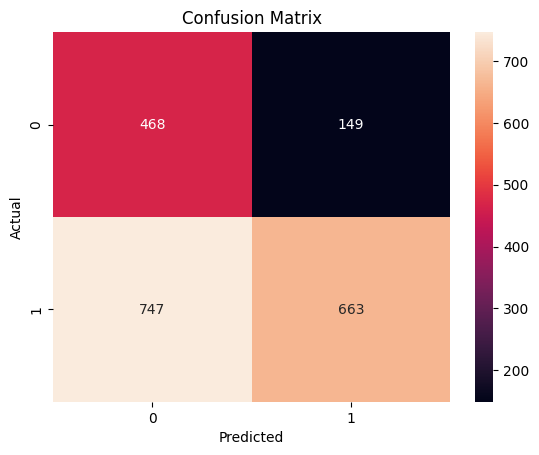

In [144]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [145]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.39      0.76      0.51       617
           1       0.82      0.47      0.60      1410

    accuracy                           0.56      2027
   macro avg       0.60      0.61      0.55      2027
weighted avg       0.69      0.56      0.57      2027



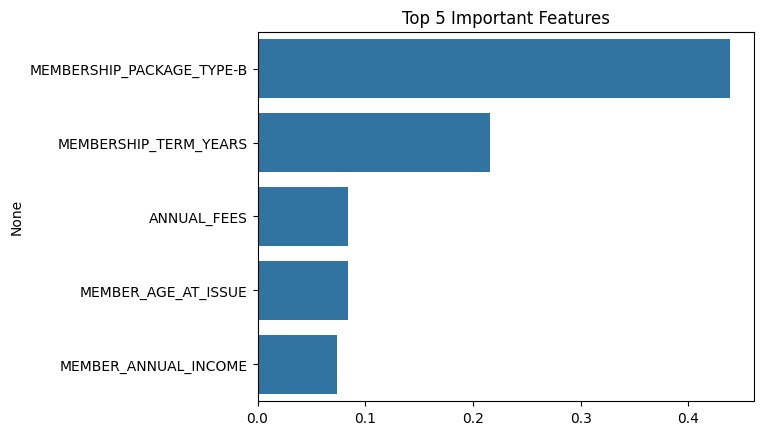

Top Features:
MEMBERSHIP_PACKAGE_TYPE-B: 0.4386
MEMBERSHIP_TERM_YEARS: 0.2158
ANNUAL_FEES: 0.0842
MEMBER_AGE_AT_ISSUE: 0.0837
MEMBER_ANNUAL_INCOME: 0.0742


In [146]:
importances = rf.feature_importances_

indices = np.argsort(importances)[::-1][:5]
top_features = X.columns[indices]
top_values = importances[indices]

sns.barplot(x=top_values, y=top_features)
plt.title("Top 5 Important Features")
plt.show()

print("Top Features:")
for f, v in zip(top_features, top_values):
    print(f"{f}: {v:.4f}")

## Conclusion

The Random Forest Classifier was implemented using 100 trees with a maximum depth of 3. After proper preprocessing and removal of irrelevant features, the model achieved an accuracy of approximately 56%.

The model is able to classify both classes, with good recall for the CANCELLED class. Feature importance analysis shows that membership package, term years, annual fees, age, and income are key influencing factors.

The model performance is moderate and realistic, and can be further improved through hyperparameter tuning.